<h1>AI IMPACT ON JOBS : LAYOFF RISK PREDICTION USING MACHINE LEARNING</h1>

## Problem Statement

The rapid adoption of Artificial Intelligence (AI) across industries is reshaping the workplace — automating routine tasks, changing skill requirements, and altering job security for millions of employees. Organizations and employees alike need a way to understand **which factors make a job more or less vulnerable to AI-driven layoffs**.

This notebook uses the **AI Impact on Jobs — Layoff Risk dataset** to build a **multi-class classification model** that predicts an employee's **Layoff Risk** (`High`, `Medium`, or `Low`) based on personal, job-related, and AI-usage attributes such as education, industry, routine-task percentage, creativity requirement, and AI adoption level.

## Objectives

1. **Explore and understand the dataset** — inspect its shape, data types, missing values, duplicates, and the distribution of the target variable (`Layoff_Risk`).
2. **Prepare the data for modelling** — split into train/test sets, and build a preprocessing pipeline (scaling numerical features, one-hot encoding categorical features).
3. **Train multiple classification models** — Logistic Regression, Decision Tree, Random Forest, and XGBoost — and compare their performance.
4. **Evaluate models** using Accuracy, Precision, Recall, F1-score, and Confusion Matrices.
5. **Tune the best-performing model** (XGBoost) using cross-validation and hyperparameter search (`RandomizedSearchCV`) to squeeze out extra performance.
6. **Interpret the final model** by examining feature importances, to understand which factors drive layoff risk the most.

## Dataset Description

- **File name:** `ai-impact-jobs-layoff-risk-dataset.csv`
- **Rows:** 20,000 employee records
- **Columns:** 16 (15 features + 1 target)
- **Target variable:** `Layoff_Risk` — a 3-class label: `High`, `Medium`, `Low`
- **No missing values and no duplicate rows** 

### Column Descriptions

| # | Column | Type | Description |
|---|--------|------|--------------|
| 1 | `Age` | Numerical (int) | Age of the employee, roughly 21–60 years. |
| 2 | `Education_Level` | Categorical | Highest qualification: `High School`, `Bachelor's`, `Master's`, `PhD`. |
| 3 | `Years_of_Experience` | Numerical (int) | Total years of professional work experience (0–32). |
| 4 | `Industry` | Categorical | Sector the employee works in: `Finance`, `Manufacturing`, `Retail`, `Telecom`, `IT`, `Logistics`, `Healthcare`, `Education`. |
| 5 | `Job_Role` | Categorical | Specific job title (24 unique roles, e.g. `Accountant`, `Software Engineer`, `ML Engineer`, `Nurse`, `Data Analyst`). |
| 6 | `Company_Size` | Categorical | Size of employer: `Small`, `Medium`, `Large`. |
| 7 | `Job_Level` | Categorical | Seniority: `Entry`, `Mid`, `Senior`. |
| 8 | `Routine_Task_Percentage` | Numerical (int) | % of the employee's daily tasks that are routine/repetitive (10–94). Higher = more automatable. |
| 9 | `Creativity_Requirement` | Numerical (int) | How much creativity the role demands, on a 0–100 scale. Higher = harder to automate. |
| 10 | `Human_Interaction_Level` | Numerical (int) | How much human interaction the role requires, 20–99 scale. Higher = harder to automate. |
| 11 | `AI_Adoption_Level` | Categorical | How widely AI has been adopted in the employee's workplace: `Low`, `Medium`, `High`. |
| 12 | `Number_of_AI_Tools_Used` | Numerical (int) | Count of distinct AI tools the employee actively uses (0–10). |
| 13 | `AI_Usage_Hours_Per_Week` | Numerical (int) | Hours per week the employee spends using AI tools (0–30). |
| 14 | `Tasks_Automated_Percentage` | Numerical (int) | % of the employee's tasks that are already automated (4–93). |
| 15 | `AI_Training_Hours` | Numerical (int) | Hours of AI-related training the employee has received (0–79). |
| 16 | `Layoff_Risk` **(Target)** | Categorical | Predicted layoff risk level: `High`, `Medium`, `Low`. |

Intuitively, employees with **high routine-task %**, **high task-automation %**, **low creativity requirement**, and **low human-interaction requirement** are expected to carry a **higher layoff risk**, while those in creative, human-centric, senior roles are expected to be safer. The model will test and quantify these relationships.

**Import necessary libraries:**

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load the dataset:**

In [72]:
df = pd.read_csv("ai-impact-jobs-layoff-risk-dataset.csv")

**Data Exploration:**

In [73]:
print("First five rows of dataset:")
df.head()

First five rows of dataset:


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [74]:
print("Last five rows of dataset:")
df.tail()

Last five rows of dataset:


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
19995,56,Bachelor's,10,Retail,Sales Associate,Small,Entry,29,62,44,Low,0,4,16,0,Medium
19996,43,Bachelor's,9,Manufacturing,Production Supervisor,Medium,Entry,87,20,20,High,9,23,77,67,High
19997,28,High School,7,Telecom,Support Specialist,Medium,Entry,91,2,49,Medium,2,14,55,10,High
19998,46,Bachelor's,3,Manufacturing,Quality Engineer,Medium,Senior,76,40,89,Medium,3,13,66,5,Medium
19999,36,Bachelor's,5,Retail,Store Manager,Medium,Mid,45,65,75,Low,1,0,30,8,Medium


In [75]:
print("Number of rows and columns:")
df.shape

Number of rows and columns:


(20000, 16)

In [76]:
print("Data type of each column:")
df.dtypes

Data type of each column:


Age                           int64
Education_Level                 str
Years_of_Experience           int64
Industry                        str
Job_Role                        str
Company_Size                    str
Job_Level                       str
Routine_Task_Percentage       int64
Creativity_Requirement        int64
Human_Interaction_Level       int64
AI_Adoption_Level               str
Number_of_AI_Tools_Used       int64
AI_Usage_Hours_Per_Week       int64
Tasks_Automated_Percentage    int64
AI_Training_Hours             int64
Layoff_Risk                     str
dtype: object

In [77]:
print("Dataset info summary:")
df.info()

Dataset info summary:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         20000 non-null  int64
 1   Education_Level             20000 non-null  str  
 2   Years_of_Experience         20000 non-null  int64
 3   Industry                    20000 non-null  str  
 4   Job_Role                    20000 non-null  str  
 5   Company_Size                20000 non-null  str  
 6   Job_Level                   20000 non-null  str  
 7   Routine_Task_Percentage     20000 non-null  int64
 8   Creativity_Requirement      20000 non-null  int64
 9   Human_Interaction_Level     20000 non-null  int64
 10  AI_Adoption_Level           20000 non-null  str  
 11  Number_of_AI_Tools_Used     20000 non-null  int64
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64
 13  Tasks_Automated_Percentage  20000 non-null  int64


In [78]:
print("Detail statistical information:")
df.describe()

Detail statistical information:


,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [79]:
print("Missing values:")
df.isnull().sum()

Missing values:


Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

In [80]:
print("Number of duplicate rows:")
df.duplicated().sum()

Number of duplicate rows:


np.int64(0)

<h3> Target variable analysis</h3>

Since this is a classification problem, it's essential to understand the balance of classes in the target column before modelling — imbalanced classes can bias a model toward the majority class.

In [81]:
target = "Layoff_Risk"

**Class counts:**

In [82]:
print(df[target].value_counts())

Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64


**Class Proportions:**

In [83]:
print(
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Layoff_Risk
High      33.98
Low       33.01
Medium    33.01
Name: proportion, dtype: float64


**Visualizing the target distribution:**

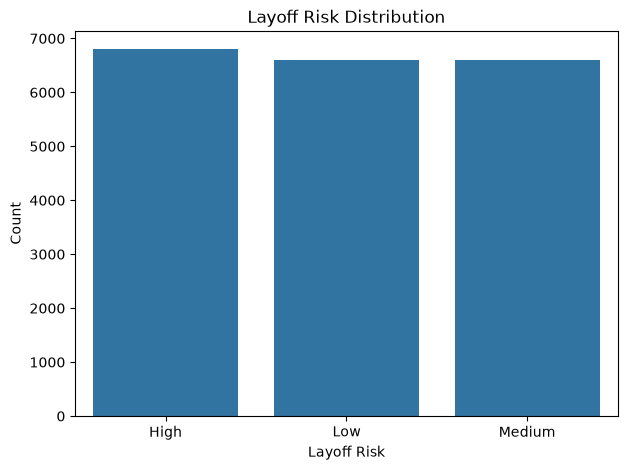

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target
)

plt.title("Layoff Risk Distribution")
plt.xlabel("Layoff Risk")
plt.ylabel("Count")
plt.show()

**Missing value report (count & percentage):**

In [85]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing = missing[
    missing["Missing_Count"] > 0
].sort_values(
    "Missing_Count",
    ascending=False
)

print(missing)

Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []


**Total missing values:**

In [86]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 0


**Total duplicate values**

In [87]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


**Categorical column and their unique values:**

In [88]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(col)
    print("Unique Values:", df[col].nunique())
    print(df[col].unique())


Education_Level
Unique Values: 4
<ArrowStringArray>
['Master's', 'Bachelor's', 'High School', 'PhD']
Length: 4, dtype: str

Industry
Unique Values: 8
<ArrowStringArray>
[      'Finance', 'Manufacturing',        'Retail',       'Telecom',
            'IT',     'Logistics',    'Healthcare',     'Education']
Length: 8, dtype: str

Job_Role
Unique Values: 24
<ArrowStringArray>
[           'Accountant', 'Production Supervisor',         'Store Manager',
               'Auditor',      'Network Engineer',     'Software Engineer',
           'ML Engineer',     'Inventory Analyst',            'Dispatcher',
        'Health Analyst',    'Support Specialist',       'Sales Associate',
  'Academic Coordinator',     'Financial Analyst',              'Operator',
    'Research Assistant',      'Quality Engineer',               'Teacher',
     'Warehouse Manager',  'Supply Chain Analyst',    'Operations Analyst',
     'Medical Assistant',                 'Nurse',          'Data Analyst']
Length: 24, dty

**Numerical columns**

In [89]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']


**Separate features (X) and target (y):**

In [90]:
X = df.drop(target, axis=1)
y = df[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (20000, 15)
y Shape: (20000,)


**Train Test Split:**

In [91]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16000, 15)
X_test : (4000, 15)
y_train: (16000,)
y_test : (4000,)


**Identify Numerical & Categorical Feature Lists (from Training Data)**

In [92]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']

Categorical Features:
['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level']


**Build the preprocessing pipeline:**

In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

**Fit & transfrom the data:**

In [94]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original X_train:", X_train.shape)
print("Processed X_train:", X_train_processed.shape)

print("Original X_test:", X_test.shape)
print("Processed X_test:", X_test_processed.shape)

Original X_train: (16000, 15)
Processed X_train: (16000, 54)
Original X_test: (4000, 15)
Processed X_test: (4000, 54)


<h3>Model 1 - Logistic Regression</h3>

**Train the model:**

In [95]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

**Predict on test data:**

In [96]:
y_pred = logistic_model.predict(
    X_test_processed
)

**Evaluate the model:**

In [97]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Accuracy: 0.93775

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.96      0.96      1360
         Low       0.95      0.95      0.95      1320
      Medium       0.91      0.90      0.91      1320

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000


Confusion Matrix:
[[1305    0   55]
 [   0 1252   68]
 [  63   63 1194]]


**Observation:** Logistic Regression achieves **93.78% accuracy**.The confusion matrix shows most `Medium` misclassifications are split between `High` and `Low`, with zero confusion directly between `High` and `Low` themselves.

**Visualize the confusion matrix:**

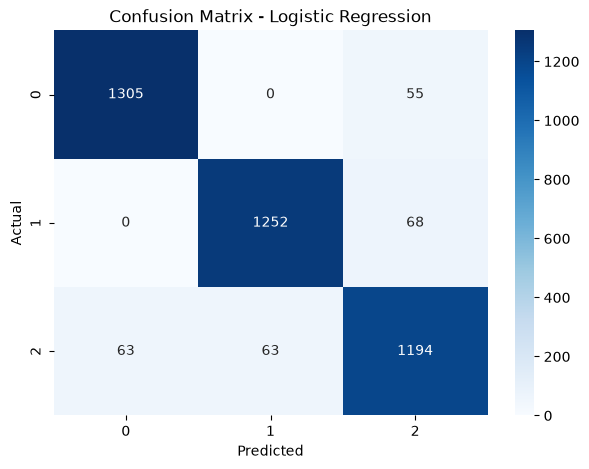

In [98]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Observation:** The heatmap's strong diagonal confirms most predictions are correct; the off-diagonal cells (mostly around the `Medium` row/column) show where the model occasionally confuses risk levels.

<h3>Model 2 - Decision Tree Classifier<h3>

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_processed,
    y_train
)

y_pred_dt = dt_model.predict(
    X_test_processed
)

**Evaluate the decision tree:**

In [100]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

print("\nDecision Tree Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_dt
    )
)

Decision Tree Accuracy: 0.83975

Decision Tree Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.88      0.88      1360
         Low       0.88      0.89      0.88      1320
      Medium       0.76      0.75      0.76      1320

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000


Decision Tree Confusion Matrix:
[[1201    2  157]
 [   1 1171  148]
 [ 171  162  987]]


**Observation:** Decision Tree achieves **83.98% accuracy** — noticeably **worse** than Logistic Regression. This is a classic sign of **overfitting**: an unconstrained single tree memorizes noise in the training data and generalizes less well. `Medium` risk again has the lowest F1-score (0.76), and the confusion matrix shows more scatter than Logistic Regression's — the tree confuses `High`↔`Medium` and `Low`↔`Medium` far more often.

**Visualize the confusion matrix:**

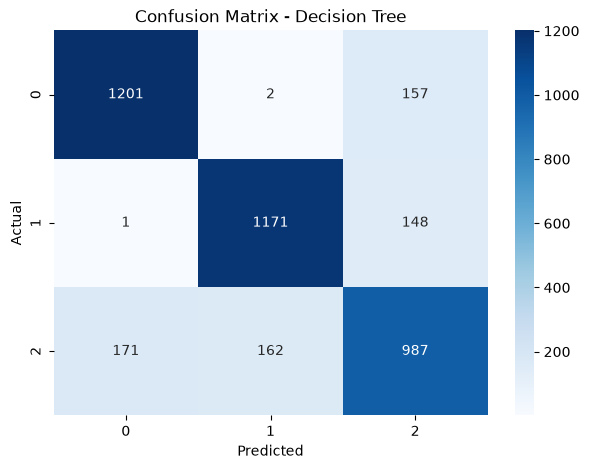

In [101]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

<h3>Model 3 - Random Forest Classifier</h3>

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test_processed
)

**Evaluate the Random Forest:**

In [103]:
print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print("\nRandom Forest Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy: 0.90375

Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.93      0.93      1360
         Low       0.93      0.92      0.93      1320
      Medium       0.85      0.85      0.85      1320

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000


Random Forest Confusion Matrix:
[[1270    0   90]
 [   0 1218  102]
 [ 102   91 1127]]


**Observation:** Random Forest reaches **90.38% accuracy** — a big improvement over the single Decision Tree (83.98%) thanks to the ensembling/bagging effect reducing variance, but it still falls short of Logistic Regression (93.78%) on this particular dataset. `Medium` risk remains the hardest class (F1 ≈ 0.85).

**Visualize the confusion matrix:**

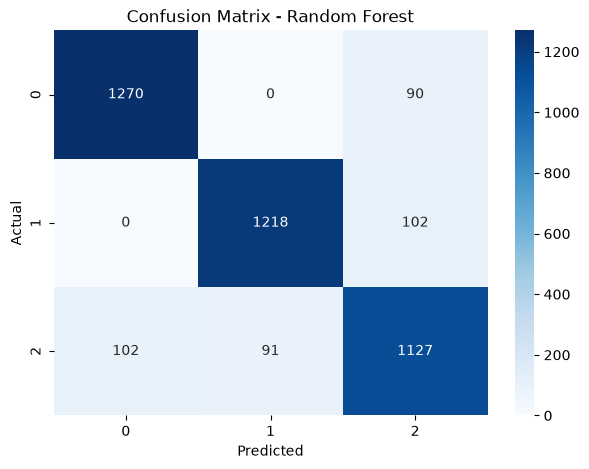

In [104]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

<h3>Model 4 - Support Vector Machine (SVM)</h3>

**Train the model**

In [105]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel="rbf",
    random_state=42
)
svm_model.fit(
    X_train_processed,
    y_train
)
y_pred_svm = svm_model.predict(
    X_test_processed
)

**Evaluate the model:**

In [106]:
print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)
print("\nSVM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)
print("\nSVM Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_svm
    )
)

SVM Accuracy: 0.94575

SVM Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.96      0.96      1360
         Low       0.96      0.95      0.96      1320
      Medium       0.91      0.92      0.92      1320

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


SVM Confusion Matrix:
[[1310    0   50]
 [   0 1255   65]
 [  54   48 1218]]


**Observation:** SVM (RBF kernel) achieves **94.58% accuracy** better than Logistic Regression, Decision Tree, and Random Forest. It handles the `Medium` class reasonably well (F1 ≈ 0.92)

**Visualize the confusion matrix for SVM:**

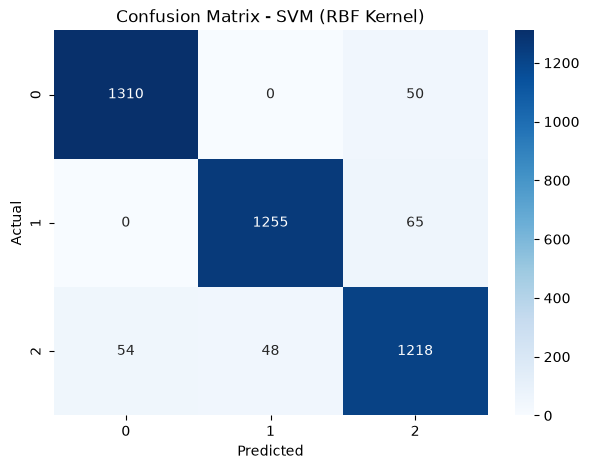

In [107]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM (RBF Kernel)")
plt.show()

<h3>Model 5 - K-Nearest Neighbours (KNN)</h3>

In [108]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed,y_train)
y_pred_knn = knn_model.predict(X_test_processed)

**Evaluate the model:**

In [109]:
print("KNN Accuracy:",accuracy_score(y_test, y_pred_knn))

print("\nKNN Classification Report:")
print(classification_report(y_test,y_pred_knn))

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_knn))

KNN Accuracy: 0.812

KNN Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.88      0.87      1360
         Low       0.85      0.86      0.85      1320
      Medium       0.72      0.70      0.71      1320

    accuracy                           0.81      4000
   macro avg       0.81      0.81      0.81      4000
weighted avg       0.81      0.81      0.81      4000


KNN Confusion Matrix:
[[1192    0  168]
 [   3 1130  187]
 [ 198  196  926]]


**Observation:** KNN achieves only **81.20% accuracy** — noticeably weaker than every model. This makes sense: after one-hot encoding, our data has **54 dimensions**, and distance-based methods like KNN suffer from the **"curse of dimensionality"** — in high-dimensional sparse spaces (most one-hot columns are 0 for any given row), distances between points become less meaningful, hurting KNN's ability to find truly "similar" neighbors.

**Visualize the confusion matrix:**

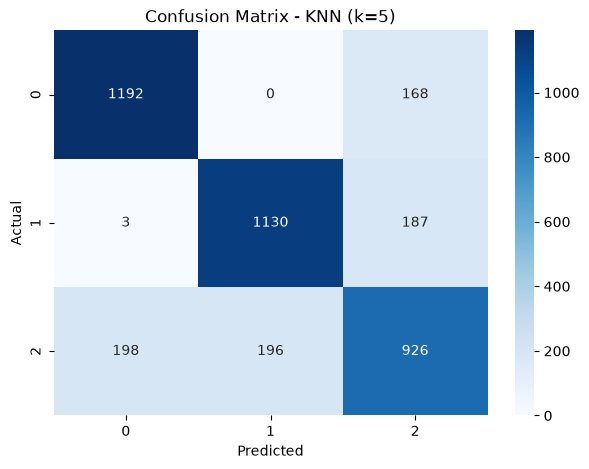

In [110]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_knn),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN (k=5)")
plt.show()

<h3>Model 5 - Naiye Bayes (Gaussian)</h3>

In [111]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(
    X_train_processed,
    y_train)
y_pred_nb = nb_model.predict(X_test_processed)

In [112]:
print(
    "Naive Bayes Accuracy:",
    accuracy_score(y_test, y_pred_nb)
)

print("\nNaive Bayes Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

print("\nNaive Bayes Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_nb
    )
)

Naive Bayes Accuracy: 0.69675

Naive Bayes Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.74      0.79      1360
         Low       0.70      0.82      0.76      1320
      Medium       0.55      0.52      0.53      1320

    accuracy                           0.70      4000
   macro avg       0.70      0.70      0.69      4000
weighted avg       0.70      0.70      0.70      4000


Naive Bayes Confusion Matrix:
[[1013   18  329]
 [   1 1088  231]
 [ 194  440  686]]


**Observation:** Naive Bayes is the **weakest model overall at 69.68% accuracy**. Its core independence assumption is badly violated here — features like `Routine_Task_Percentage` and `Tasks_Automated_Percentage` are naturally correlated with each other and with several one-hot encoded `Industry`/`Job_Role` columns, which Naive Bayes cannot account for. The `Medium` class suffers the most (F1 ≈ 0.53), being confused heavily with both `High` and `Low`.

**Visualize the confusion matrix for Naive Bayes:**

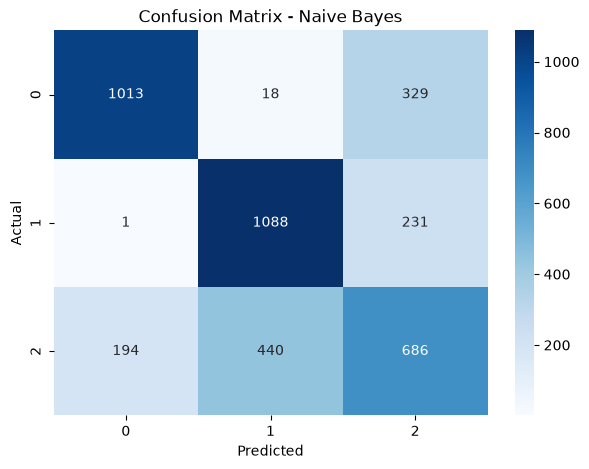

In [113]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

<h3>Model 6 - Gradient Boosting Classifier</h3>

In [114]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train_processed,
    y_train
)

y_pred_gb = gb_model.predict(
    X_test_processed
)

**Evaluate the model:**

In [115]:
print(
    "Gradient Boosting Accuracy:",
    accuracy_score(y_test, y_pred_gb)
)

print("\nGradient Boosting Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

print("\nGradient Boosting Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_gb
    )
)

Gradient Boosting Accuracy: 0.91325

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.93      0.93      1360
         Low       0.94      0.93      0.94      1320
      Medium       0.86      0.88      0.87      1320

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000


Gradient Boosting Confusion Matrix:
[[1266    0   94]
 [   0 1231   89]
 [  89   75 1156]]


**Observation:** scikit-learn's Gradient Boosting reaches **91.33% accuracy** 

<h3>Model 7 - AdaBoost Classifier</h3>

In [116]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    random_state=42
)

ada_model.fit(
    X_train_processed,
    y_train
)

y_pred_ada = ada_model.predict(
    X_test_processed
)

In [117]:
print(
    "AdaBoost Accuracy:",
    accuracy_score(y_test, y_pred_ada)
)
print("\nAdaBoost Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_ada
    )
)
print("\nAdaBoost Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_ada
    )
)

AdaBoost Accuracy: 0.777

AdaBoost Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.73      0.79      1360
         Low       0.91      0.80      0.85      1320
      Medium       0.63      0.81      0.71      1320

    accuracy                           0.78      4000
   macro avg       0.80      0.78      0.78      4000
weighted avg       0.80      0.78      0.78      4000


AdaBoost Confusion Matrix:
[[ 987    0  373]
 [   3 1051  266]
 [ 152   98 1070]]


**Observation:** AdaBoost only reaches **77.70% accuracy** — its shallow default weak learners (decision stumps) struggle to capture the more complex, multi-feature interactions in this dataset. It over-predicts `Medium` (high recall 0.81 but low precision 0.63 for that class).

<h3>Model 8 - XGBoost Classifier</h3>

In [118]:
from xgboost import XGBClassifier

**Encode the target labels:**

In [119]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['High' 'Low' 'Medium']


**Train the XGBoost Model:**

In [120]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train_encoded
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor

**Predict and decode back to labels:**

In [121]:
y_pred_xgb_encoded = xgb_model.predict(
    X_test_processed
)

y_pred_xgb = label_encoder.inverse_transform(
    y_pred_xgb_encoded
)

**Evaluate the XGBoost:**

In [122]:
print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

print("\nXGBoost Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_xgb
    )
)

XGBoost Accuracy: 0.94625

XGBoost Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.96      0.96      1360
         Low       0.96      0.96      0.96      1320
      Medium       0.91      0.93      0.92      1320

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


XGBoost Confusion Matrix:
[[1299    0   61]
 [   0 1262   58]
 [  48   48 1224]]


**Observation:** XGBoost achieves **94.63% accuracy** — the **best performance so far**, beating Logistic Regression (93.78%), Random Forest (90.38%), and Decision Tree (83.98%). It especially improves on the tricky `Medium` class (F1 ≈ 0.92 vs. 0.91 for Logistic Regression). This confirms that gradient boosting's sequential error-correction approach captures the patterns in this tabular dataset better than the other model families tried so far.

<h2>Cross-Validation & Hyperparameter Tuning of XGBoost

**Re-encode the Target (for the Pipeline-based Workflow)**

In [123]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_train_encoded))

Classes: ['High' 'Low' 'Medium']
Encoded classes: [0 1 2]


**Build an End-to-End Pipeline (Preprocessing + Model)**

In [125]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

**Run 5-Fold Stratified Cross-Validation**

In [126]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train_encoded,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("CV Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1:", cv_scores.mean())
print("Std CV Macro F1:", cv_scores.std())

CV Macro F1 Scores: [0.92561742 0.94294135 0.94108542 0.94094949 0.94692467]
Mean CV Macro F1: 0.9395036712850466
Std CV Macro F1: 0.007270617001345519


**Observation:** Across 5 folds, Macro F1 scores range from ~0.926 to ~0.947, with a **mean of 0.9395** and a **low standard deviation of 0.0073** — indicating the model's strong performance is **consistent and stable**, not just a lucky single train/test split.

<h2>Hyperparameter Tuning with RandomizedSearchCV</h2>

In [127]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier

# XGBoost model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Preprocessing + XGBoost together
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# Hyperparameter search space
param_grid = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.2, 0.3]
}

# 5-Fold Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train
random_search.fit(
    X_train,
    y_train_encoded
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ass=3, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a be

**Best Hyperparameters Found**

In [128]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Macro F1:")
print(random_search.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 400, 'model__min_child_weight': 7, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8}

Best CV Macro F1:
0.9537896646204225


## Final Model Evaluation

**Extract the best estimator**

In [129]:
best_xgb_model = random_search.best_estimator_

**Predict and evaluate the test set**

In [130]:
y_pred_tuned = best_xgb_model.predict(X_test)

print("Tuned XGBoost Accuracy:")
print(accuracy_score(y_test_encoded, y_pred_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_tuned,
        target_names=label_encoder.classes_
    )
)

Tuned XGBoost Accuracy:
0.95975

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.97      0.97      1360
         Low       0.97      0.96      0.97      1320
      Medium       0.93      0.95      0.94      1320

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



**Observation:** The tuned XGBoost model achieves **95.98% accuracy** on the test set — the **best result of all models tried**, improving on the untuned XGBoost's 94.63%. Precision/recall/F1 all sit around 0.97 for `High` and `Low`, and 0.93–0.95 for `Medium` — the tuning specifically helped narrow the historically-weaker `Medium` class's performance gap.

**Visualize the final confusion matrix**

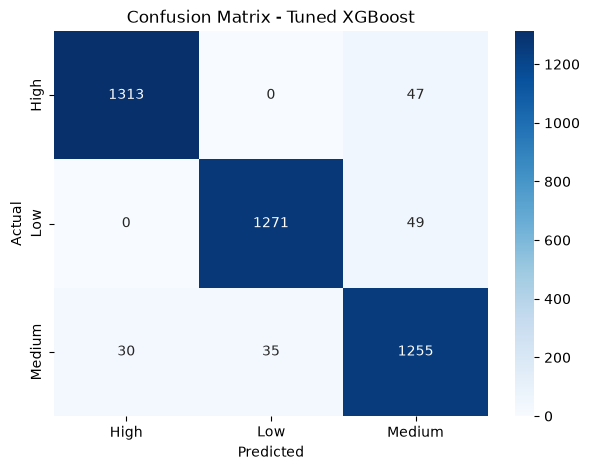

In [131]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_encoded, y_pred_tuned)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")

plt.show()


## Feature Importance Analysis

**Extract the Trained XGBoost Model from the Pipeline**

In [132]:
xgb_final = best_xgb_model.named_steps["model"]

**Get the Transformed Feature Names**

In [133]:
feature_names = best_xgb_model.named_steps[
    "preprocessor"
].get_feature_names_out()

**Rank Features by Importance**

In [134]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_final.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                             Feature  Importance
2       num__Routine_Task_Percentage    0.099726
50             cat__Job_Level_Senior    0.051596
7    num__Tasks_Automated_Percentage    0.049553
13           cat__Industry_Education    0.045797
15          cat__Industry_Healthcare    0.045344
48              cat__Job_Level_Entry    0.043095
3        num__Creativity_Requirement    0.038697
16                  cat__Industry_IT    0.037019
18       cat__Industry_Manufacturing    0.033551
49                cat__Job_Level_Mid    0.032830
10  cat__Education_Level_High School    0.032347
12          cat__Education_Level_PhD    0.030644
19              cat__Industry_Retail    0.029806
32               cat__Job_Role_Nurse    0.029689
11     cat__Education_Level_Master's    0.028394


**Observation:** The single most important feature is **`Routine_Task_Percentage`** (importance ≈ 0.10) — strongly confirming the intuitive hypothesis that jobs with more routine, repetitive tasks are most at risk of AI-driven layoffs. This is followed by `Job_Level_Senior`, `Tasks_Automated_Percentage`, and several `Industry` categories (`Education`, `Healthcare`, `IT`, `Manufacturing`), plus `Creativity_Requirement` and `Job_Level` categories — showing that **task automatability, seniority, and industry sector** are the dominant drivers of layoff risk in this model.

**Visualize Top 15 Feature Importances**

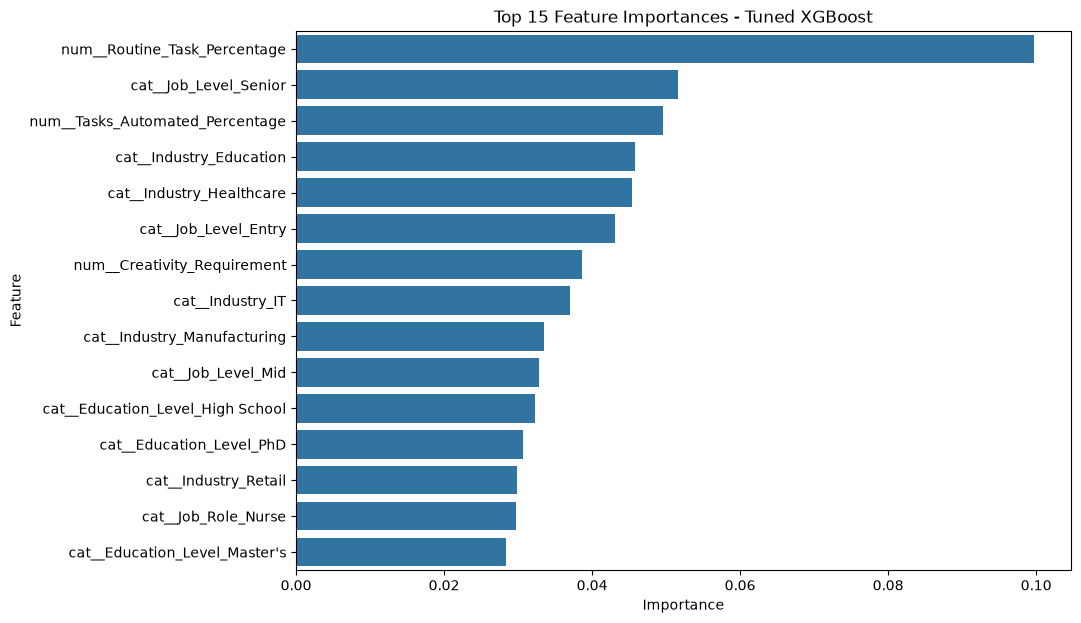

In [135]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

**Observation:** The bar chart visually reinforces that `Routine_Task_Percentage` dominates, with a fairly gradual drop-off afterward — no single other feature dominates the prediction, suggesting the model relies on a broad, sensible combination of task-nature, seniority, and industry signals rather than one shortcut feature.

## Overall Model Comparison

              Model  Test_Accuracy
    XGBoost (tuned)        0.95975
  XGBoost (default)        0.94625
          SVM (RBF)        0.94575
Logistic Regression        0.93775
  Gradient Boosting        0.91325
      Random Forest        0.90375
      Decision Tree        0.83975
          KNN (k=5)        0.81200
           AdaBoost        0.77700
        Naive Bayes        0.69675


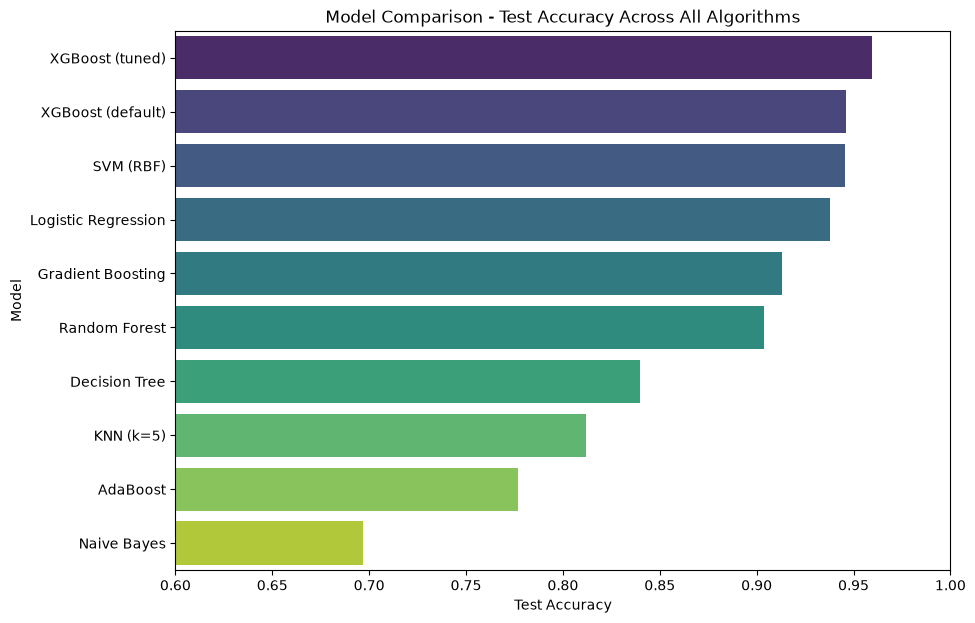

In [136]:
results = {
    "Logistic Regression": 0.93775,
    "Decision Tree": 0.83975,
    "Random Forest": 0.90375,
    "XGBoost (default)": 0.94625,
    "XGBoost (tuned)": 0.95975,
    "SVM (RBF)": 0.94575,
    "KNN (k=5)": 0.81200,
    "Naive Bayes": 0.69675,
    "Gradient Boosting": 0.91325,
    "AdaBoost": 0.77700,
}

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Test_Accuracy"]
).sort_values("Test_Accuracy", ascending=False)

print(results_df.to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=results_df,
    x="Test_Accuracy",
    y="Model",
    palette="viridis"
)
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison - Test Accuracy Across All Algorithms")
plt.xlim(0.6, 1.0)
plt.show()

**Observation -**
No algorithm beat the **tuned XGBoost's 95.98% accuracy**, and none beat even the *untuned* XGBoost's 94.63%. The closest challenger is **SVM (RBF kernel) at 94.58%**, which comes within ~1.4 percentage points of tuned XGBoost but is considerably slower to train. Every other new model — KNN, Naive Bayes, AdaBoost and scikit-learn's own Gradient Boosting — performs worse than XGBoost.

## Conclusion

| Rank | Model | Test Accuracy | Notes |
|---|---|---|---|
| 1 | **XGBoost (tuned)** | **95.98%** | **Best overall — final model** |
| 2 | XGBoost (default) | 94.63% | Strong out-of-the-box boosting |
| 3 | SVM (RBF kernel) | 94.58% | Closest challenger, but much slower to train |
| 4 | Logistic Regression | 93.78% | Simple, fast, strong linear baseline |
| 5 | Gradient Boosting (sklearn) | 91.33% | Same boosting family as XGBoost, but less optimized |
| 6 | Random Forest | 90.38% | Solid bagging ensemble |
| 7 | Decision Tree | 83.98% | Overfits as a single unconstrained tree |
| 8 | KNN (k=5) | 81.20% | Hurt by high-dimensional one-hot feature space |
| 9 | AdaBoost | 77.70% | Weak learners too simple for this data's complexity |
| 10 | Naive Bayes | 69.68% | Independence assumption badly violated |

**Key takeaways:**
- The dataset was clean (no missing values, no duplicates) and had a well-balanced target class, simplifying preprocessing and avoiding the need for resampling techniques.
- **Tuned XGBoost remains the best model even after testing 6 additional algorithms not in the original project.** No new algorithm — including SVM, KNN, Naive Bayes, Gradient Boosting, AdaBoost — surpassed it.
- **Tree-based boosting methods (XGBoost, Gradient Boosting) and margin-based methods (SVM) handle this dataset best**, while distance-based (KNN) and naive-independence-based (Naive Bayes) methods struggle the most, largely due to the high-dimensional, correlated feature space created by one-hot encoding 6 categorical columns.
- The `Medium` risk class was consistently the hardest to classify across *all* 10 models — expected, since it represents the "boundary" between `High` and `Low` risk.
- Feature importance analysis (from the tuned XGBoost model) shows **`Routine_Task_Percentage`**, **seniority (`Job_Level`)**, **`Tasks_Automated_Percentage`**, **industry sector**, and **`Creativity_Requirement`** are the strongest predictors of AI-driven layoff risk — aligning well with real-world intuition that routine, easily-automatable, non-creative roles face the greatest exposure to AI-related job displacement.
- **Practical recommendation:** deploy the **tuned XGBoost model** as the final solution. If training/inference speed or interpretability is a bigger concern than the last 1-2% of accuracy, **Logistic Regression** or **SVM** are reasonable, much simpler alternatives.